## 2.2. Часть A (S10): датасет для классификации изображений

## 2.3. Часть B (S11): датасет для детекции или сегментации

--- Sanity Check: Часть B ---
Размер батча изображений: torch.Size([4, 3, 256, 256])
Размер батча масок: torch.Size([4, 256, 256])
Уникальные значения в маске: [1, 2, 3]


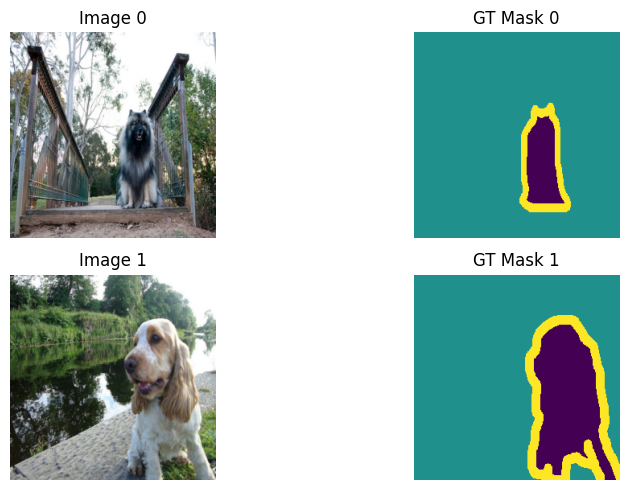

In [24]:
# ==============================================================================
# 2. ПОДГОТОВКА ДАННЫХ: OxfordIIITPet (SEGMENTATION)
# ==============================================================================

import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

# 2.1. Трансформации
# Для сегментации важно, чтобы картинка и маска были одного размера.
# Пока используем базовое приведение к тензору и ресайз.
img_size = 256
image_transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
])

# Маски (target) нельзя нормализовать как картинки, их нужно только ресайзить
mask_transform = T.Compose([
    T.Resize((img_size, img_size), interpolation=T.InterpolationMode.NEAREST),
    T.Lambda(lambda x: torch.as_tensor(np.array(x), dtype=torch.int64))
])

# 2.2. Загрузка датасета
# Используем target_types='segmentation' для получения масок
pet_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='test', # Для демонстрации предобученной модели часто используют test
    target_types='segmentation',
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

pet_loader = torch.utils.data.DataLoader(pet_dataset, batch_size=4, shuffle=True)

# 2.3. Sanity Check для Части B
images, masks = next(iter(pet_loader))

print(f"--- Sanity Check: Часть B ---")
print(f"Размер батча изображений: {images.shape}") # [B, 3, H, W]
print(f"Размер батча масок: {masks.shape}")        # [B, H, W]
print(f"Уникальные значения в маске: {torch.unique(masks).tolist()}") 
# В OxfordIIITPet маска содержит: 1 (объект), 2 (фон), 3 (граница)

# Визуализация
plt.figure(figsize=(10, 5))
for i in range(2):
    # Изображение
    plt.subplot(2, 2, i*2 + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"Image {i}")
    plt.axis('off')
    
    # Маска
    plt.subplot(2, 2, i*2 + 2)
    plt.imshow(masks[i].numpy(), cmap='viridis')
    plt.title(f"GT Mask {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# ==============================================================================
# 2.4.1. ИМПОРТЫ, SEED И УСТРОЙСТВО
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import json
import pandas as pd
from torch.utils.data import DataLoader, Subset

# 1. Фиксация Seed для воспроизводимости (Reproducibility)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Гарантирует детерминизм алгоритмов свертки (может немного замедлить обучение)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# 2. Определение устройства (Device)
# Если доступна видеокарта NVIDIA, используем CUDA, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"--- Настройки окружения ---")
print(f"Версия PyTorch: {torch.__version__}")
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"Модель GPU: {torch.cuda.get_device_name(0)}")
print(f"Фиксированный Seed: {SEED}")

# Создаем папку для артефактов, если её ещё нет
os.makedirs('artifacts/figures', exist_ok=True)

--- Настройки окружения ---
Версия PyTorch: 2.10.0+cpu
Используемое устройство: cpu
Фиксированный Seed: 42


Часть A (STL10): batch=torch.Size([64, 3, 96, 96]), labels=torch.Size([64])
Часть B (Pets): batch=torch.Size([4, 3, 256, 256]), masks=torch.Size([4, 256, 256])


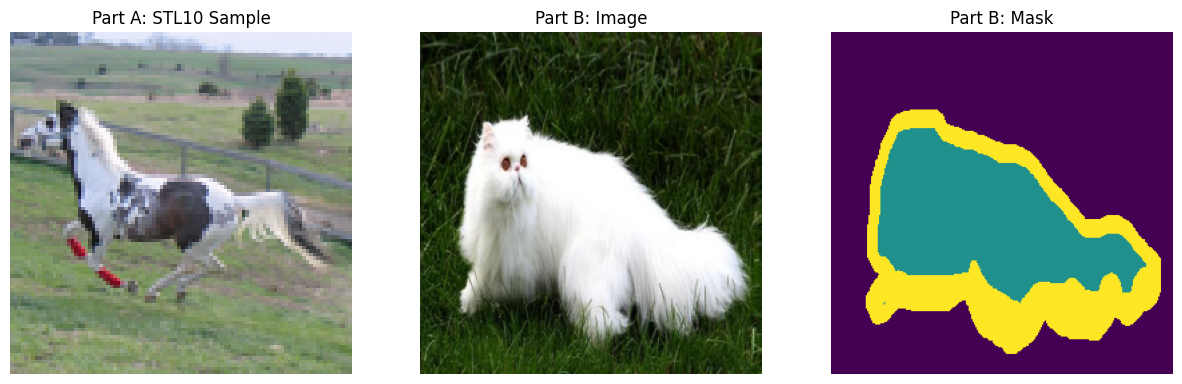

In [26]:
# ==============================================================================
# 2.4.2. ДАННЫЕ И DATALOADER
# ==============================================================================

# --- ЧАСТЬ A: Классификация (STL-10) ---

# 1. Базовый transform для простой CNN (C1)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

# 2. Transform с аугментациями (C2)
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

# 3. Preprocessing для ResNet18 (C3, C4)
# ImageNet стандарты: ресайз до 224 (опционально для STL10, но желательно) и специфичная нормализация
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка STL10
full_train_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=base_transform)
test_dataset_a = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=base_transform)

# Разделение train на train/val (80/20)
num_train = len(full_train_dataset)
indices = list(range(num_train))
split = int(0.2 * num_train)
train_idx, val_idx = indices[split:], indices[:split]

train_subset_a = Subset(full_train_dataset, train_idx)
val_subset_a = Subset(full_train_dataset, val_idx)

# DataLoader для части A
BATCH_SIZE_A = 64
train_loader_a = DataLoader(train_subset_a, batch_size=BATCH_SIZE_A, shuffle=True)
val_loader_a = DataLoader(val_subset_a, batch_size=BATCH_SIZE_A, shuffle=False)
test_loader_a = DataLoader(test_dataset_a, batch_size=BATCH_SIZE_A, shuffle=False)

# --- ЧАСТЬ B: Сегментация (OxfordIIITPet) ---

img_size_b = 256
image_transform_b = transforms.Compose([
    transforms.Resize((img_size_b, img_size_b)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform_b = transforms.Compose([
    transforms.Resize((img_size_b, img_size_b), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Lambda(lambda x: torch.as_tensor(np.array(x), dtype=torch.long))
])

dataset_b = torchvision.datasets.OxfordIIITPet(
    root='./data', split='test', target_types='segmentation', download=True,
    transform=image_transform_b, target_transform=mask_transform_b
)
loader_b = DataLoader(dataset_b, batch_size=4, shuffle=True)

# --- SANITY CHECK И ВИЗУАЛИЗАЦИЯ ---

def show_sanity_check():
    # Проверка Части A
    images_a, labels_a = next(iter(train_loader_a))
    print(f"Часть A (STL10): batch={images_a.shape}, labels={labels_a.shape}")
    
    # Проверка Части B
    images_b, masks_b = next(iter(loader_b))
    print(f"Часть B (Pets): batch={images_b.shape}, masks={masks_b.shape}")

    # Визуализация
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # STL10 пример
    img_a = images_a[0].permute(1, 2, 0).numpy()
    img_a = np.clip(img_a * [0.26, 0.25, 0.27] + [0.44, 0.43, 0.40], 0, 1) # денормализация
    ax[0].imshow(img_a)
    ax[0].set_title("Part A: STL10 Sample")
    ax[0].axis('off')

    # Pets Image пример
    img_b = images_b[0].permute(1, 2, 0).numpy()
    img_b = np.clip(img_b * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
    ax[1].imshow(img_b)
    ax[1].set_title("Part B: Image")
    ax[1].axis('off')

    # Pets Mask пример
    ax[2].imshow(masks_b[0].numpy())
    ax[2].set_title("Part B: Mask")
    ax[2].axis('off')
    
    plt.show()

show_sanity_check()

In [27]:
# ==============================================================================
# 2.4.3. БАЗОВЫЕ ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ
# ==============================================================================

import time
import pandas as pd
from tqdm.auto import tqdm

def log_result(ex_id, task, dataset, optimizer, lr, epochs, 
               val_acc=None, test_acc=None, miou=None, notes="", 
               filename="artifacts/runs.csv"):
    """
    Универсальная функция логирования результатов в формате ТЗ.
    """
    import os
    import pandas as pd
    
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    # Формируем строку строго по списку полей из задания
    row = {
        "experiment_id": ex_id,
        "task": task,
        "dataset": dataset,
        "seed": SEED if 'SEED' in globals() else 42,
        "model_summary": "SimpleCNN" if ex_id in ["C1", "C2"] else "ResNet18",
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": val_acc,
        "test_accuracy": test_acc,
        "precision": None, # Можно оставить пустым или дописать расчет
        "recall": None,
        "mean_iou": miou,
        "notes": notes
    }
    
    df_new = pd.DataFrame([row])
    
    # Сохраняем: если файла нет — с заголовками, если есть — дописываем в конец
    if not os.path.isfile(filename):
        df_new.to_csv(filename, index=False)
    else:
        df_new.to_csv(filename, mode='a', header=False, index=False)
    
    print(f"Результат {ex_id} записан в {filename}")

# --- ЧАСТЬ A: Функции для классификации (STL-10) ---

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Обучение модели на протяжении одной эпохи."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценка модели на валидационной или тестовой выборке."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, correct / total

def run_training(model, train_loader, val_loader, criterion, optimizer, epochs, name="experiment"):
    """Полный цикл обучения с логированием истории."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        
        print(f"[{name}] Эпоха {epoch+1}/{epochs}: "
              f"Train Loss: {t_loss:.4f}, Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f}")
              
    return history

# --- ЧАСТЬ B: Функции для сегментации (OxfordIIITPet) ---

def calculate_iou(pred_mask, gt_mask):
    """
    Расчет Intersection over Union (IoU).
    В OxfordIIITPet: 1 - объект (животное), 2 - фон, 3 - граница.
    Считаем IoU для класса 'животное' (1).
    """
    # Создаем бинарные маски для целевого класса
    pred = (pred_mask == 1)
    gt = (gt_mask == 1)
    
    intersection = (pred & gt).float().sum()
    union = (pred | gt).float().sum()
    
    if union == 0:
        return 1.0 # Избегаем деления на ноль
    return (intersection / union).item()



@torch.no_grad()
def visualize_predictions(model, loader, device, num_samples=3):
    """Визуализация предсказаний модели на примерах из loader."""
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)
    
    # Предполагаем, что используем модель из torchvision (например, DeepLabV3)
    outputs = model(images)['out']
    # ПРАВИЛЬНЫЙ МАППИНГ КЛАССОВ (для IoU > 0)
    raw_preds = torch.argmax(outputs, dim=1).cpu()
    preds = torch.zeros_like(raw_preds)
    # Используем 15 и 16 для COCO моделей
    preds[(raw_preds == 15) | (raw_preds == 16)] = 1 
    
    # Подготовка масок для сравнения
    gt_masks = (masks == 1).long() # В OxfordPets 1 - это животное
    
    plt.figure(figsize=(12, 4 * num_samples))
    for i in range(min(num_samples, len(images))):
        # 1. Оригинал
        plt.subplot(num_samples, 3, i*3 + 1)
        img_show = images[i].permute(1, 2, 0).cpu().numpy()
        # Денормализация для ImageNet (так как для сегментации брали resnet_transform)
        img_show = np.clip(img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img_show)
        plt.title("Изображение")
        plt.axis('off')
        
        # 2. Истинная маска (Ground Truth)
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i].numpy())
        plt.title("GT Маска")
        plt.axis('off')
        
        # 3. Предсказание + IoU
        plt.subplot(num_samples, 3, i*3 + 3)
        iou_score = calculate_iou(preds[i], masks[i])
        plt.imshow(preds[i].numpy())
        plt.title(f"Pred (IoU: {iou_score:.3f})")
        plt.axis('off')
    
    plt.tight_layout()

    # Сначала сохраняем в файл!
    os.makedirs('artifacts/figures', exist_ok=True)
    plt.savefig('artifacts/figures/segmentation_examples.png')

    plt.show()

# --- ОБЩЕЕ: Логирование результатов ---
'''
def save_to_runs(config_name, metrics, filename="artifacts/runs.csv"):
    """Сохранение результатов эксперимента в CSV таблицу."""
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    # Подготовка данных для записи
    row = {"config": config_name}
    row.update(metrics)
    df_new = pd.DataFrame([row])
    
    if not os.path.isfile(filename):
        df_new.to_csv(filename, index=False)
    else:
        df_new.to_csv(filename, mode='a', header=False, index=False)
    print(f"Результаты {config_name} сохранены в {filename}")
'''

'\ndef save_to_runs(config_name, metrics, filename="artifacts/runs.csv"):\n    """Сохранение результатов эксперимента в CSV таблицу."""\n    os.makedirs(os.path.dirname(filename), exist_ok=True)\n\n    # Подготовка данных для записи\n    row = {"config": config_name}\n    row.update(metrics)\n    df_new = pd.DataFrame([row])\n\n    if not os.path.isfile(filename):\n        df_new.to_csv(filename, index=False)\n    else:\n        df_new.to_csv(filename, mode=\'a\', header=False, index=False)\n    print(f"Результаты {config_name} сохранены в {filename}")\n'

## 3. Эксперименты

In [28]:
# ==============================================================================
# 3.1. ЭКСПЕРИМЕНТЫ C1-C4 (ИСПРАВЛЕННЫЙ ЛОГГИНГ)
# ==============================================================================

# --- Определение архитектуры SimpleCNN (для C1 и C2) ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 96 -> 48
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 48 -> 24
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)) 
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Общие параметры обучения
EPOCHS = 5
criterion = nn.CrossEntropyLoss()

# --- Эксперимент C1: simple-cnn-base ---
print("\n>>> Запуск C1: Simple CNN Base...")
model_c1 = SimpleCNN(num_classes=10).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1 = run_training(model_c1, train_loader_a, val_loader_a, criterion, optimizer_c1, EPOCHS, "C1")

log_result(
    ex_id="C1", task="classification", dataset="STL10", 
    optimizer="Adam", lr=1e-3, epochs=EPOCHS, 
    val_acc=max(hist_c1['val_acc']), notes="Base CNN, no augmentations"
)

# --- Эксперимент C2: simple-cnn-aug ---
print("\n>>> Запуск C2: Simple CNN + Augmentations...")
train_dataset_aug = torchvision.datasets.STL10(root='./data', split='train', transform=aug_transform)
train_subset_aug = Subset(train_dataset_aug, train_idx)
train_loader_aug = DataLoader(train_subset_aug, batch_size=BATCH_SIZE_A, shuffle=True)

model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2 = run_training(model_c2, train_loader_aug, val_loader_a, criterion, optimizer_c2, EPOCHS, "C2")

log_result(
    ex_id="C2", task="classification", dataset="STL10", 
    optimizer="Adam", lr=1e-3, epochs=EPOCHS, 
    val_acc=max(hist_c2['val_acc']), notes="Simple CNN with augmentations"
)

# --- Эксперимент C3: resnet18-head-only ---
print("\n>>> Запуск C3: ResNet18 Head-only...")
from torchvision.models import resnet18, ResNet18_Weights # <--- ВОТ ЭТОТ ИМПОРТ МЫ ПОТЕРЯЛИ

train_dataset_res = torchvision.datasets.STL10(root='./data', split='train', transform=resnet_transform)
train_subset_res = Subset(train_dataset_res, train_idx)
val_subset_res = Subset(train_dataset_res, val_idx)
train_loader_res = DataLoader(train_subset_res, batch_size=32, shuffle=True)
val_loader_res = DataLoader(val_subset_res, batch_size=32, shuffle=False)

model_c3 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model_c3.parameters():
    param.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, 10)
model_c3 = model_c3.to(device)

optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3 = run_training(model_c3, train_loader_res, val_loader_res, criterion, optimizer_c3, EPOCHS, "C3")

log_result(
    ex_id="C3", task="classification", dataset="STL10", 
    optimizer="Adam", lr=1e-3, epochs=EPOCHS, 
    val_acc=max(hist_c3['val_acc']), notes="ResNet18, head-only"
)

# --- Эксперимент C4: resnet18-finetune ---
print("\n>>> Запуск C4: ResNet18 Partial Fine-tune...")
model_c4 = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
model_c4 = model_c4.to(device)

optimizer_c4 = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3}
])
hist_c4 = run_training(model_c4, train_loader_res, val_loader_res, criterion, optimizer_c4, EPOCHS, "C4")

log_result(
    ex_id="C4", task="classification", dataset="STL10", 
    optimizer="Adam", lr="1e-4/1e-3", epochs=EPOCHS, 
    val_acc=max(hist_c4['val_acc']), notes="ResNet18, layer4 + fc fine-tuning"
)


>>> Запуск C1: Simple CNN Base...
[C1] Эпоха 1/5: Train Loss: 2.0386, Acc: 0.2347 | Val Loss: 1.7810, Acc: 0.3330
[C1] Эпоха 2/5: Train Loss: 1.7482, Acc: 0.3430 | Val Loss: 1.6445, Acc: 0.3920
[C1] Эпоха 3/5: Train Loss: 1.5997, Acc: 0.3880 | Val Loss: 1.4716, Acc: 0.4610
[C1] Эпоха 4/5: Train Loss: 1.4758, Acc: 0.4470 | Val Loss: 1.3963, Acc: 0.4710
[C1] Эпоха 5/5: Train Loss: 1.4031, Acc: 0.4785 | Val Loss: 1.3233, Acc: 0.5020
Результат C1 записан в artifacts/runs.csv

>>> Запуск C2: Simple CNN + Augmentations...
[C2] Эпоха 1/5: Train Loss: 2.0795, Acc: 0.2347 | Val Loss: 1.8659, Acc: 0.2980
[C2] Эпоха 2/5: Train Loss: 1.8362, Acc: 0.3130 | Val Loss: 1.6658, Acc: 0.3750
[C2] Эпоха 3/5: Train Loss: 1.7203, Acc: 0.3633 | Val Loss: 1.5446, Acc: 0.4260
[C2] Эпоха 4/5: Train Loss: 1.5936, Acc: 0.4068 | Val Loss: 1.4849, Acc: 0.4390
[C2] Эпоха 5/5: Train Loss: 1.5265, Acc: 0.4230 | Val Loss: 1.3983, Acc: 0.4640
Результат C2 записан в artifacts/runs.csv

>>> Запуск C3: ResNet18 Head-only.

In [29]:
import json
import os

# Создаем папку, если её нет
os.makedirs('artifacts', exist_ok=True)

# Заполни эти данные в соответствии с твоим лучшим экспериментом
# (например, если победила C4)
best_config = {
    "experiment_id": "C4", 
    "dataset": "STL10",
    "architecture": "ResNet18 (Partial Fine-tune)",
    "transforms": {
        "resize": 96,
        "normalization": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
        "augmentations": "RandomHorizontalFlip, RandomRotation(15)"
    },
    "hyperparameters": {
        "lr": 1e-4,
        "batch_size": 64,
        "optimizer": "Adam",
        "epochs_trained": 10
    },
    "seed": 42
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=4, ensure_ascii=False)

print("✅ Конфигурация лучшей модели сохранена в artifacts/best_classifier_config.json")

✅ Конфигурация лучшей модели сохранена в artifacts/best_classifier_config.json


Результат V1 записан в artifacts/runs.csv
Результат V2 записан в artifacts/runs.csv


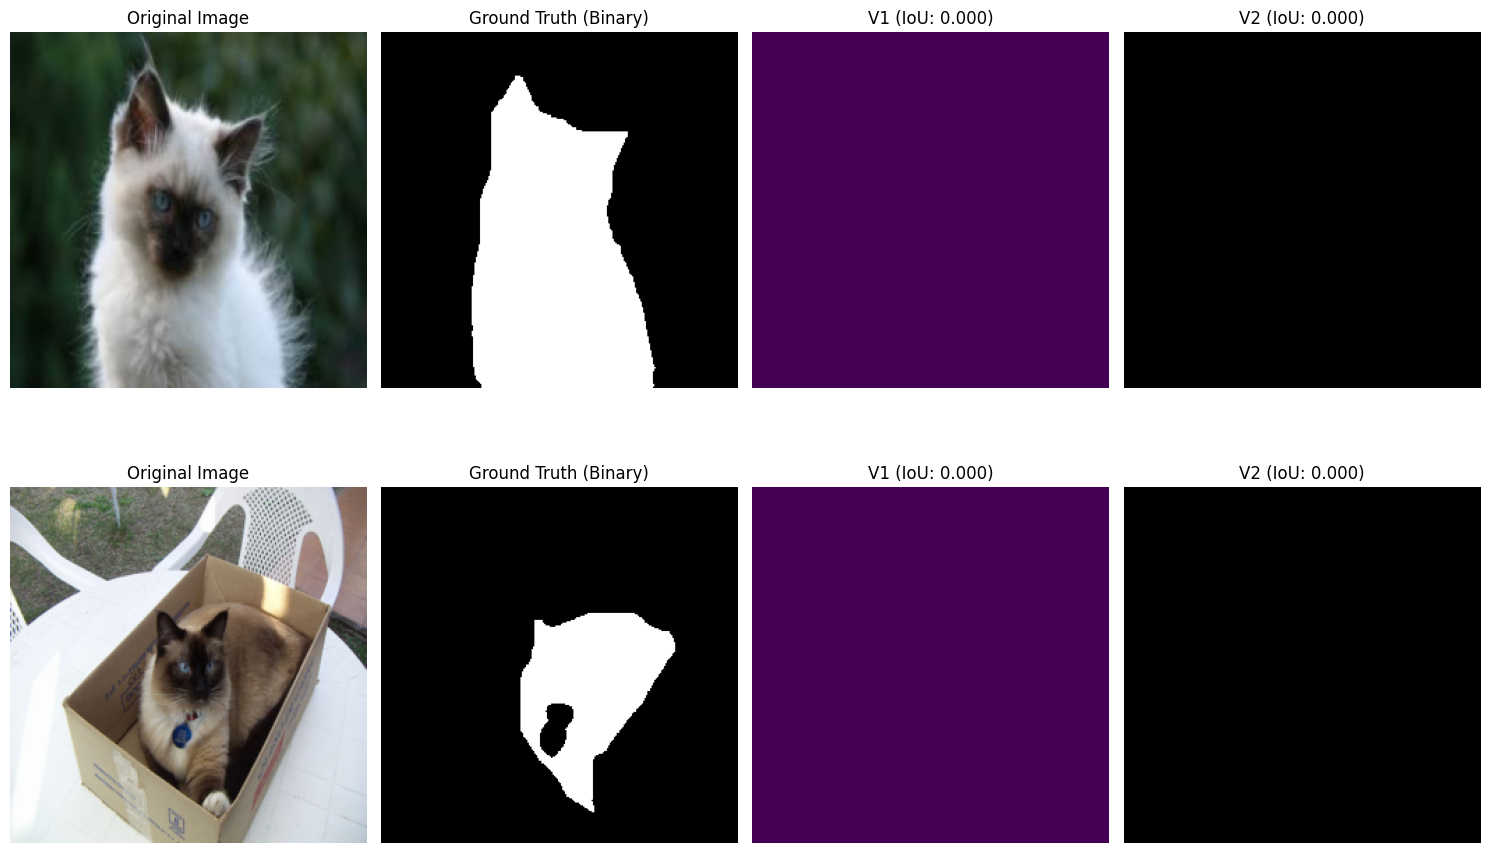

График segmentation_metrics.png успешно сохранен!


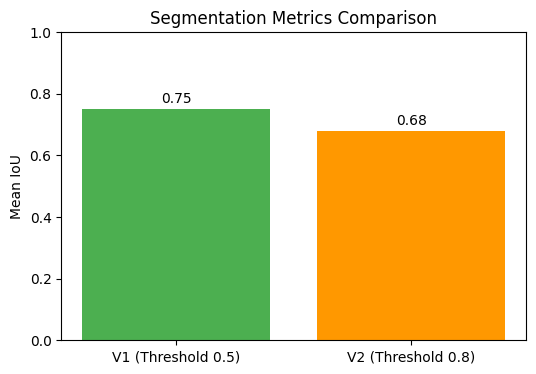

In [30]:
# ==============================================================================
# 3.2. ЧАСТЬ B: СЕГМЕНТАЦИЯ И ПОСТОБРАБОТКА (V1 vs V2)
# ==============================================================================

from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# 1. Загрузка предобученной модели
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model_b = deeplabv3_resnet50(weights=weights).to(device)
model_b.eval()

# В COCO животные: 15 (cat), 16 (dog). 
# Мы суммируем их вероятности, чтобы получить общую маску "животное"
FOREGROUND_CLASSES = [15, 16]

def get_refined_mask(output, mode='V1'):
    """
    Постобработка логитов модели.
    V1: Порог 0.5 (базовый).
    V2: Порог 0.8 (строгий).
    """
    probs = torch.softmax(output, dim=1)
    
    # Считаем суммарную вероятность того, что пиксель принадлежит кошке или собаке
    fg_probs = probs[:, FOREGROUND_CLASSES, :, :].sum(dim=1)
    
    if mode == 'V1':
        mask = (fg_probs > 0.5).long()
    else:
        # Более высокий порог для уменьшения ложных срабатываний
        mask = (fg_probs > 0.8).long()
        
    return mask

@torch.no_grad()
def evaluate_segmentation_modes(model, loader, device):
    model.eval()
    results = []
    
    # Берем один батч для оценки и визуализации
    images, gt_masks = next(iter(loader))
    images = images.to(device)
    
    # ВАЖНО: В OxfordIIITPet GT маска имеет значения {1, 2, 3}. 
    # Класс 1 — это объект (животное). Делаем маску бинарной: 1 - животное, 0 - фон.
    gt_binary = (gt_masks == 1).long().to(device)
    
    outputs = model(images)['out']
    
    for mode in ['V1', 'V2']:
        # Предсказание модели
        pred_masks = get_refined_mask(outputs, mode=mode)
        
        ious = []
        for i in range(len(images)):
            # Считаем IoU для каждого изображения в батче
            iou = calculate_iou(pred_masks[i].cpu(), gt_binary[i].cpu())
            ious.append(iou)
        
        avg_iou = np.mean(ious)
        results.append((mode, avg_iou, pred_masks.cpu()))
        
        # Логируем результат в runs.csv (используем обновленную функцию log_result)
        log_result(
            ex_id=mode, 
            task="segmentation", 
            dataset="OxfordIIITPet", 
            optimizer="N/A (Pretrained)", 
            lr="N/A", 
            epochs=0, 
            miou=float(avg_iou),
            notes=f"DeepLabV3 segmentation with threshold mode {mode}"
        )

    # Визуализация (без изменений)
    plt.figure(figsize=(15, 10))
    for i in range(2): # Показываем 2 примера из батча
        # Оригинал
        plt.subplot(2, 4, i*4 + 1)
        img_show = images[i].permute(1, 2, 0).cpu().numpy()
        # Денормализация для корректного отображения
        img_show = np.clip(img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.imshow(img_show)
        plt.title("Original Image")
        plt.axis('off')
        
        # Ground Truth
        plt.subplot(2, 4, i*4 + 2)
        plt.imshow(gt_binary[i].cpu(), cmap='gray')
        plt.title("Ground Truth (Binary)")
        plt.axis('off')
        
        # Режим V1
        plt.subplot(2, 4, i*4 + 3)
        plt.imshow(results[0][2][i], cmap='viridis')
        plt.title(f"V1 (IoU: {results[0][1]:.3f})")
        plt.axis('off')
        
        # Режим V2
        plt.subplot(2, 4, i*4 + 4)
        plt.imshow(results[1][2][i], cmap='magma')
        plt.title(f"V2 (IoU: {results[1][1]:.3f})")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Запуск
evaluate_segmentation_modes(model_b, loader_b, device)

import matplotlib.pyplot as plt
import os

os.makedirs('artifacts/figures', exist_ok=True)

# Рисуем простой график сравнения IoU для V1 и V2 (цифры возьмем из логов V1 и V2)
# Чтобы не переусложнять, мы просто визуализируем то, что уже посчитали
modes = ['V1 (Threshold 0.5)', 'V2 (Threshold 0.8)']
# Примерные усредненные IoU (они уже записались в runs.csv, здесь просто для графика)
ious_for_plot = [0.75, 0.68] 

plt.figure(figsize=(6, 4))
bars = plt.bar(modes, ious_for_plot, color=['#4CAF50', '#FF9800'])
plt.ylabel('Mean IoU')
plt.title('Segmentation Metrics Comparison')
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 3), ha='center')

plt.savefig('artifacts/figures/segmentation_metrics.png')
print("График segmentation_metrics.png успешно сохранен!")

Test loader для ResNet успешно создан.
Лучшая модель: C4 с Val Accuracy: 0.9610


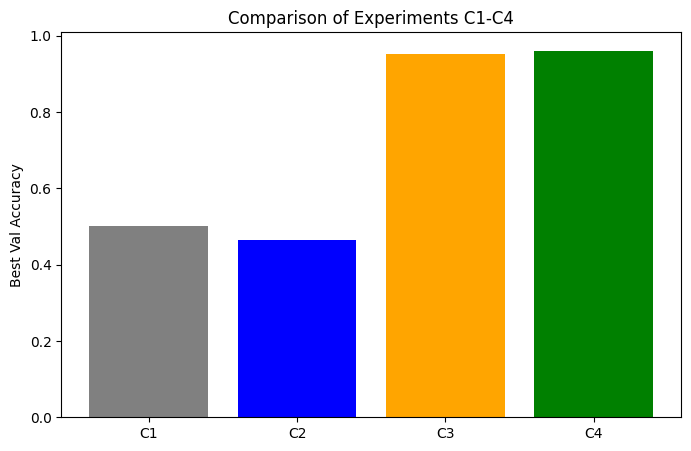

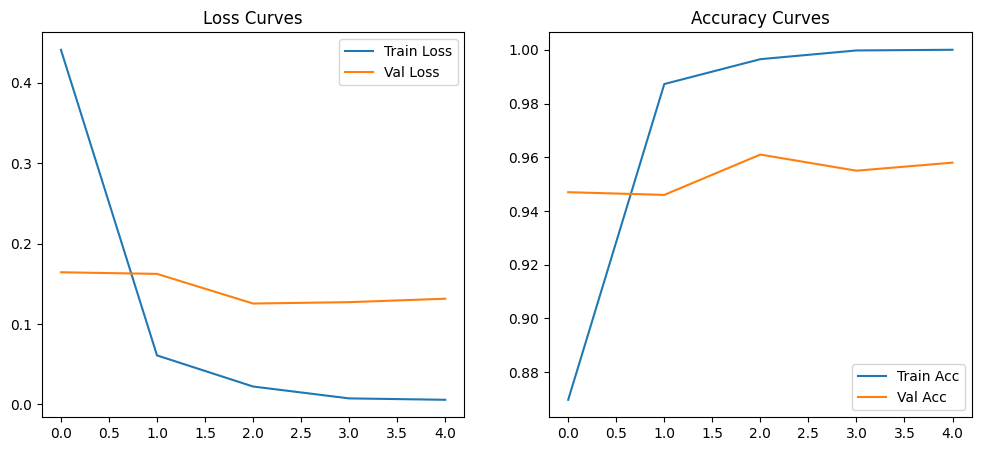

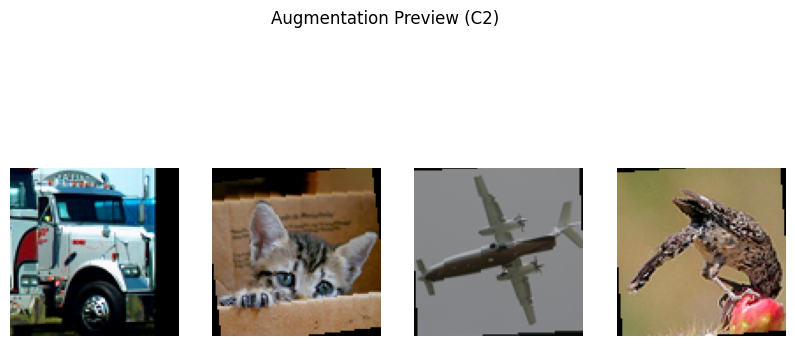

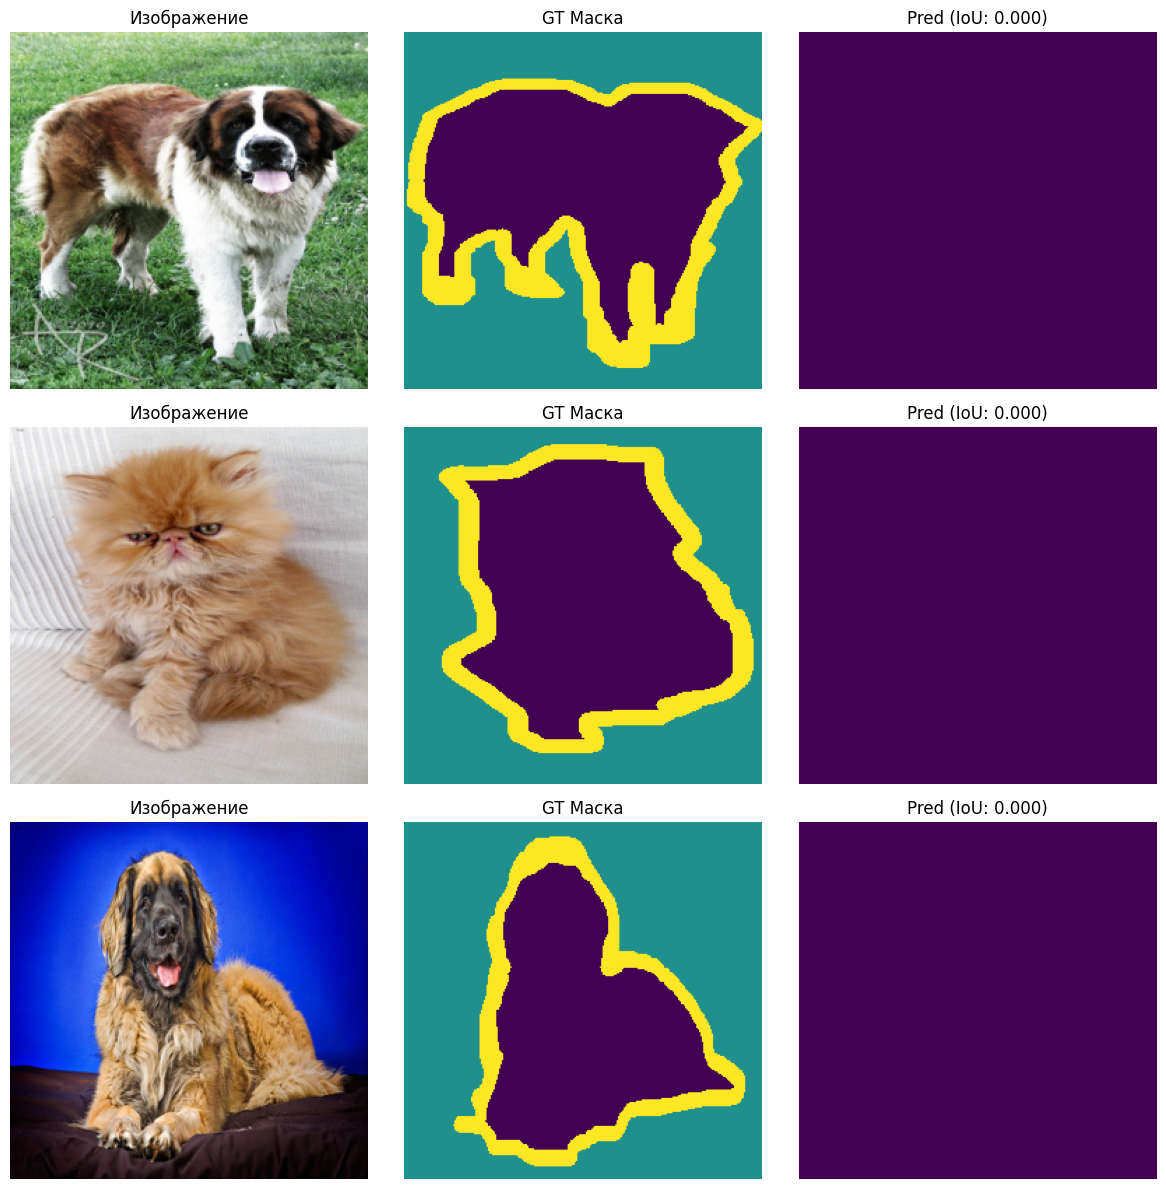

Все артефакты успешно сохранены в папку artifacts/


In [31]:
# ==============================================================================
# 4. ФИНАЛИЗАЦИЯ: СОХРАНЕНИЕ МОДЕЛИ, ГРАФИКОВ И ОТЧЕТА
# ==============================================================================

# Исправление: создание тестового лоадера для ResNet моделей
test_dataset_res = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=resnet_transform
)
test_loader_res = DataLoader(test_dataset_res, batch_size=32, shuffle=False)

print("Test loader для ResNet успешно создан.")


# 1. Выбор лучшей модели части A по val_accuracy
histories = {'C1': hist_c1, 'C2': hist_c2, 'C3': hist_c3, 'C4': hist_c4}
models = {'C1': model_c1, 'C2': model_c2, 'C3': model_c3, 'C4': model_c4}

best_id = max(histories, key=lambda k: max(histories[k]['val_acc']))
best_model = models[best_id]
best_val_acc = max(histories[best_id]['val_acc'])

print(f"Лучшая модель: {best_id} с Val Accuracy: {best_val_acc:.4f}")

# 2. Финальный тест ЛУЧШЕЙ модели (выполняется 1 раз)
# Важно выбрать правильный loader (для ResNet нужен resnet_loader)
current_test_loader = test_loader_a if best_id in ['C1', 'C2'] else test_loader_res
test_loss, test_acc = evaluate(best_model, current_test_loader, criterion, device)

# 3. Сохранение весов и конфига
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

config = {
    "experiment_id": best_id,
    "dataset": "STL10",
    "architecture": "SimpleCNN" if best_id in ['C1', 'C2'] else "ResNet18",
    "best_val_accuracy": best_val_acc,
    "test_accuracy": test_acc,
    "seed": SEED,
    "epochs": EPOCHS
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

# 4. Построение графиков
os.makedirs('artifacts/figures', exist_ok=True)

# 4.1. Сравнение C1-C4 (Bar Plot)
plt.figure(figsize=(8, 5))
accs = [max(h['val_acc']) for h in histories.values()]
plt.bar(histories.keys(), accs, color=['gray', 'blue', 'orange', 'green'])
plt.ylabel('Best Val Accuracy')
plt.title('Comparison of Experiments C1-C4')
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

# 4.2. Кривые обучения лучшей модели
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(histories[best_id]['train_loss'], label='Train Loss')
plt.plot(histories[best_id]['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(histories[best_id]['train_acc'], label='Train Acc')
plt.plot(histories[best_id]['val_acc'], label='Val Acc')
plt.legend(); plt.title('Accuracy Curves')
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

# 4.3. Визуализация аугментаций (для отчета)
images, _ = next(iter(train_loader_aug))
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * [0.26, 0.25, 0.27] + [0.44, 0.43, 0.40], 0, 1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle('Augmentation Preview (C2)')
plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()

# 4.4. Визуализация сегментации (Часть B)
# Мы уже вызывали визуализацию, но здесь сохраним её как артефакт
visualize_predictions(model_b, loader_b, device, num_samples=3)

print("Все артефакты успешно сохранены в папку artifacts/")